In [1]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy
import os 

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
sns.set_style('whitegrid')

#switch dir and load packages
#check if /app is in Path.cwd() and if not, switch to the root of the repo
if 'app' not in [p.name for p in Path.cwd().parents]:
    os.chdir(r'..\..')

from dataclasses import dataclass
from typing import List, Tuple, Dict

from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs, compute_lcc, lcc_plot, recategorize_cost

# Path of WJK
working_dir = Path(r"c:\Users\klerk_wj\Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")
# Path of Yida
# working_dir = Path(r"C:\Users\tao\OneDrive - Stichting Deltares\KIA – Aanpasbaar en Uitbreidbaar - Documents\WP3 casestudies\2c WIP casus WSSS\designs toolbox KOSWAT")

sns.set_palette("husl", 12)
colors = sns.color_palette("husl", 12)




## Uitwerking adaptatiepad - basis gevoeligheidsanalyse levensduur


We gaan uit van een toename van de benodigde kruin van 1.8 cm/jaar als basisscenario. 
Daarin zit 0.3 cm/jaar als compensatie voor bodemdaling, en 1.5 cm/jaar voor ZSS.
In de scnearios kan dit laatste deel 50% sneller of 50% langzamer verlopen.

We beginnen in dit geval met een forse overhoogte: er hoeft pas in 2075 met 60 cm versterkt te worden voor zichtjaar 2125. 

Terugrekenend betekent dit dat 60 cm nodig is om 100 jaar bodemdaling = 30 cm plus 100 jaar ZSS  = 150 cm extra HBN te compenseren. 

Op dit moment is er dus een overhoogte van 120 centimeter.


Wanneer we kijken naar een constructie is de gangbare levensduur 100 jaar. We kijken naar een scenario met 50 jaar en 150 jaar levensduur van de verankerde damwand.
De investeringen in de damwand beschouwen we afzonderlijk.


In [2]:
#Relaties K(V) and V(dh) for soil and structure
K_V_soil= (35.35484753346291, 322077.9547159534)
V_dh_soil = (11471.387096774197, 14325.854838709674)
K_V_structure = (45.18322635984883, 19811.642431342385)
V_dh_structure = (6614.22702127614, 11385.050760739967)

#Kosten initiele grondversterking 2025:
C_init_grondversterking_2025 = 1317010.27 + 1300000 #bouwkosten + vastgoed (zie andere Notebook)

In [3]:


@dataclass
class ScenarioResult:
    """Results for a single scenario (ZSS_speed, lifespan combination)"""
    zss_speed: float
    lifespan: int
    costs: List[Tuple[int, float]]              # [(year, cost), ...]
    volumes: List[Tuple[int, float]]            # [(year, volume), ...]
    structures: List[Tuple[int, str]]           # [(year, structure_type), ...]
    crest_increases: List[Tuple[int, float]]    # [(year, increase), ...]
    overhoogte: List[float]                     # Height over time
    
    @property
    def total_cost(self) -> float:
        """Total investment cost across all interventions"""
        return sum(c for _, c in self.costs)
    
    @property
    def num_interventions(self) -> int:
        """Number of interventions in this scenario"""
        return len(self.costs) - 1  # Exclude initial cost
    
    @property
    def final_height(self) -> float:
        """Final crest height"""
        return self.overhoogte[-1] if self.overhoogte else 0


@dataclass
class AdaptationPathwayAnalysis:
    """Complete analysis results for all scenarios"""
    scenario_parameters: Dict
    scenarios: Dict[Tuple[float, int], ScenarioResult]
    
    def get_scenario(self, zss_speed: float, lifespan: int) -> ScenarioResult:
        """Get results for a specific scenario"""
        return self.scenarios[(zss_speed, lifespan)]
    
    def to_dataframe(self) -> pd.DataFrame:
        """Convert scenarios to analysis DataFrame"""
        data = []
        for (zss, life), result in self.scenarios.items():
            max_increase = max((c for _, c in result.crest_increases), default=0) if result.crest_increases else 0
            data.append({
                'ZSS_speed_cm_yr': zss,
                'Lifespan_yr': life,
                'Total_Cost_EUR': result.total_cost,
                'Num_Interventions': result.num_interventions,
                'Max_Crest_Increase_cm': max_increase,
                'Final_Height_cm': result.final_height
            })
        return pd.DataFrame(data)
    
    def summary_by_zss(self) -> pd.DataFrame:
        """Summary statistics grouped by ZSS speed"""
        df = self.to_dataframe()
        return df.groupby('ZSS_speed_cm_yr').agg({
            'Total_Cost_EUR': ['min', 'mean', 'max'],
            'Num_Interventions': ['min', 'mean', 'max']
        })


In [6]:
def compute_scenario_structure(
    ZSS_speed,
    life,
    h_0,
    dh_crest,
    costs_dict,
    V_dh_structure,
    K_V_structure,
    outer_measures=False,
    buyout_year=1e99,
    **kwargs,
 ):
    """
    Compute adaptation pathway for a single ZSS speed and lifespan scenario.

    Strategy split:
    - Before buyout year: structure-based interventions.
    - From buyout year onward: optional one-time buyout + soil-based interventions.

    Returns:
    - costs_made, volumes_added, structures_made, crest_increase, overhoogte
    """

    # Core state
    costs_made = [(0, costs_dict['damwand'])]
    volumes_added = [(0, 0)]
    structures_made = [(0, 'Verankerde damwand')]
    crest_increase = [(0, 0)]
    total_increase = 0
    overhoogte = [h_0]
    remaining_life_local = life
    buyout_done = False

    # Optional settings
    max_interventions = kwargs.get('max_interventions', 3)
    buyout_cost = kwargs.get('buyout_cost', costs_dict.get('Uitkoop', 0.0))
    C_berm = kwargs.get('C_berm', 1317010.27)
    V_dh_soil = kwargs.get('V_dh_soil', (11471.387096774197, 14325.854838709674))
    K_V_soil = kwargs.get('K_V_soil', (35.35484753346291, 322077.9547159534))

    if outer_measures:
        kosten_verruwing = kwargs.get('kosten_verruwing', 1e8)
        kosten_kruinmuur = kwargs.get('kosten_kruinmuur', 1e8)
        kruinmuur_built = False
        verruwing_built = False

    def append_action(t, cost, volume, structure):
        costs_made.append((t, cost))
        volumes_added.append((t, volume))
        structures_made.append((t, structure))

    def compute_volume_and_cost(dcrest_cm, V_dh, K_V, extra_cost=0.0):
        volume = V_dh[0] * (dcrest_cm / 100) + V_dh[1]
        cost = K_V[0] * volume + K_V[1] + extra_cost
        return volume, cost

    def maybe_apply_outer_measure(t, dcrest_cm):
        """Apply verruwing/kruinmuur first (if enabled and still available)."""
        nonlocal remaining_life_local, verruwing_built, kruinmuur_built

        if not outer_measures:
            return False

        if verruwing_built and kruinmuur_built:
            return False

        if not verruwing_built:
            append_action(t, kosten_verruwing, 0, 'Verruwing')
            print(f"In {t+2025} wordt een verruwing aangelegd. Kosten: {kosten_verruwing:,.0f} euro")
            verruwing_built = True
        elif not kruinmuur_built:
            append_action(t, kosten_kruinmuur, 0, 'Kruinmuur')
            print(f"In {t+2025} wordt een kruinmuur gebouwd. Kosten: {kosten_kruinmuur:,.0f} euro")
            kruinmuur_built = True

        # If remaining structure life is low, combine with kistdam replacement.
        if remaining_life_local < 20:
            volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_structure, K_V_structure, costs_dict['kistdam'])
            prev_cost = costs_made[-1][1]
            structures_made[-1] = (t, structures_made[-1][1] + ' en kistdam')
            volumes_added[-1] = (t, volume)
            costs_made[-1] = (t, prev_cost + cost)
            remaining_life_local = 100
            print(
                f"In {t+2025} wordt de kruin verhoogd met {structures_made[-1][1]} cm en de constructie vervangen door een kistdam. "
                f"Kosten: {costs_made[-1][1]:,.0f} euro"
            )

        return True

    def handle_structure_strategy(t, dcrest_cm):
        """Pre-buyout: perform structure-based intervention."""
        nonlocal remaining_life_local

        # Try outer measures first when available.
        if maybe_apply_outer_measure(t, dcrest_cm):
            return

        if remaining_life_local < 20:
            volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_structure, K_V_structure, costs_dict['kistdam'])
            append_action(t, cost, volume, 'Kistdam')
            remaining_life_local = 100
            print(f"In {t+2025} wordt de kruin verhoogd met {dcrest_cm} cm en de constructie vervangen door een kistdam. Kosten: {cost:,.0f} euro")
            return

        if 200 < total_increase <= 300:
            volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_structure, K_V_structure, costs_dict['oplassen_buispalen'])
            append_action(t, cost, volume, 'Oplassen met buispalen')
            print(
                f"In {t+2025} wordt de kruin verhoogd met {dcrest_cm} cm en de constructie uitgebreid door oplassen met buispalen. "
                f"Kosten: {cost:,.0f} euro"
            )
            return

        if total_increase > 300 and 'Kistdam' not in [s[1] for s in structures_made]:
            volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_structure, K_V_structure, costs_dict['kistdam'])
            append_action(t, cost, volume, 'Kistdam')
            remaining_life_local = 100
            print(f"In {t+2025} wordt de kruin verhoogd met {dcrest_cm} cm en de constructie vervangen door een kistdam. Kosten: {cost:,.0f} euro")
            return

        if total_increase > 300 and 'Kistdam' in [s[1] for s in structures_made]:
            volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_structure, K_V_structure, costs_dict['oplassen'])
            append_action(t, cost, volume, 'Oplassen')
            print(
                f"In {t+2025} wordt de kruin verhoogd met {dcrest_cm} cm en de kistdam uitgebreid door oplassen. "
                f"Kosten: {cost:,.0f} euro"
            )
            return

        volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_structure, K_V_structure, costs_dict['oplassen'])
        append_action(t, cost, volume, 'Oplassen')
        print(f"In {t+2025} wordt de kruin verhoogd met {dcrest_cm} cm en de constructie uitgebreid door oplassen. Kosten: {cost:,.0f} euro")

    def handle_post_buyout_soil_strategy(t, dcrest_cm):
        """Post-buyout: one-time buyout and then soil-based interventions."""
        nonlocal buyout_done

        if not buyout_done and t >= buyout_year:
            append_action(t, buyout_cost, 0, 'Uitkoop')
            buyout_done = True
            print(f"In {t+2025} wordt uitgekocht. Kosten: {buyout_cost:,.0f} euro")

        volume, cost = compute_volume_and_cost(dcrest_cm, V_dh_soil, K_V_soil, 0.0)
        if remaining_life_local > 20:
            append_action(t, cost, volume, 'Kruinverhoging')
        else:
            append_action(t, cost + C_berm, volume, 'Grondversterking')

        overhoogte[-1] += dcrest_cm
        print(f"In {t+2025} wordt een grondmaatregel uitgevoerd met {dcrest_cm} cm kruinverhoging. Kosten: {costs_made[-1][1]:,.0f} euro")

    for t in np.arange(1, 175, 1):
        overhoogte.append(overhoogte[-1] - dh_crest - ZSS_speed)
        remaining_life_local -= 1
        dcrest = 0

        if overhoogte[-1] < 0:
            if len(costs_made) >= max_interventions:
                break

            dcrest = dh_crest * 50 + ZSS_speed * 50
            total_increase += dcrest
            overhoogte[-1] += dcrest

            if t < buyout_year:
                handle_structure_strategy(t, dcrest)
            else:
                handle_post_buyout_soil_strategy(t, dcrest)

        elif remaining_life_local == 0 and t < buyout_year:
            if len(costs_made) >= max_interventions:
                break

            dcrest = max(dh_crest * 50 + ZSS_speed * 50 - overhoogte[-1], 0)
            if dcrest > 0:
                total_increase += dcrest
                volume, cost = compute_volume_and_cost(dcrest, V_dh_structure, K_V_structure, costs_dict['kistdam'])
                append_action(t, cost, volume, 'Kistdam')
                print(
                    f"In {t+2025} wordt de constructie vervangen door een kistdam en de kruin verhoogd met {dcrest} cm. "
                    f"Kosten: {cost:,.0f} euro"
                )
            else:
                append_action(t, costs_dict['kistdam'], 0, 'Kistdam')
                print(f"In {t+2025} wordt de constructie vervangen door een kistdam. Kosten: {costs_dict['kistdam']:,.0f} euro")

            overhoogte[-1] += dcrest
            remaining_life_local = 100

        if dcrest > 0:
            crest_increase.append((t, dcrest))

    return costs_made, volumes_added, structures_made, crest_increase, overhoogte


ZSS_base_rate = 1.4
scenario_ZSS_cm_jaar = [ZSS_base_rate * .50, ZSS_base_rate, ZSS_base_rate * 1.5]
scenario_ZSS_cm_jaar = [round(x, 1) for x in scenario_ZSS_cm_jaar]
lifespan = [50, 100, 150]

costs_dict = {
    'damwand': 5000000,
    'kistdam': 5000000,
    'oplassen': 1800000,
    'oplassen_buispalen': 3200000,
    'Uitkoop': 0,
}

h_0 = 100
dh_crest = 0.3

# Single source of truth for structure scenarios
results_dict = {}

for ZSS_speed in scenario_ZSS_cm_jaar:
    print(f"Scenario ZSS snelheid: {ZSS_speed} cm/jaar")
    for life in lifespan:
        print(f"Scenario levensduur: {life} jaar")

        costs_made, volumes_added, structures_made, crest_increase, overhoogte = compute_scenario_structure(
            ZSS_speed, life, h_0, dh_crest, costs_dict, V_dh_structure, K_V_structure
        )

        results_dict[(ZSS_speed, life)] = ScenarioResult(
            zss_speed=ZSS_speed,
            lifespan=life,
            costs=costs_made,
            volumes=volumes_added,
            structures=structures_made,
            crest_increases=crest_increase,
            overhoogte=overhoogte,
        )

analysis = AdaptationPathwayAnalysis(
    scenario_parameters={
        'costs_dict': costs_dict,
        'h_0': h_0,
        'dh_crest': dh_crest,
        'V_dh_structure': V_dh_structure,
        'K_V_structure': K_V_structure,
        'scenario_ZSS_cm_jaar': scenario_ZSS_cm_jaar,
        'lifespan': lifespan,
    },
    scenarios=results_dict,
 )

analysis_df = analysis.to_dataframe()
analysis_df

Scenario ZSS snelheid: 0.7 cm/jaar
Scenario levensduur: 50 jaar
In 2075 wordt de constructie vervangen door een kistdam. Kosten: 5,000,000 euro
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie uitgebreid door oplassen. Kosten: 2,483,651 euro
Scenario levensduur: 100 jaar
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie vervangen door een kistdam. Kosten: 5,683,651 euro
In 2175 wordt de kruin verhoogd met 50.0 cm en de constructie uitgebreid door oplassen. Kosten: 2,483,651 euro
Scenario levensduur: 150 jaar
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie uitgebreid door oplassen. Kosten: 2,483,651 euro
In 2175 wordt de kruin verhoogd met 50.0 cm en de constructie vervangen door een kistdam. Kosten: 5,683,651 euro
Scenario ZSS snelheid: 1.4 cm/jaar
Scenario levensduur: 50 jaar
In 2075 wordt de constructie vervangen door een kistdam en de kruin verhoogd met 69.99999999999997 cm. Kosten: 5,743,421 euro
In 2126 wordt de kruin verhoogd met 85.0 cm en 

,ZSS_speed_cm_yr,Lifespan_yr,Total_Cost_EUR,Num_Interventions,Max_Crest_Increase_cm,Final_Height_cm
0,0.7,50,1.248365e+07,2,50.0,-6.661338e-16
1,0.7,100,1.316730e+07,2,50.0,2.600000e+01
2,0.7,150,1.316730e+07,2,50.0,2.600000e+01
3,1.4,50,1.333167e+07,2,85.0,1.085798e-13
4,1.4,100,1.333167e+07,2,85.0,-1.700000e+00
5,1.4,150,1.017650e+07,2,85.0,1.500000e+01
6,2.1,50,1.498570e+07,2,120.0,-8.000000e-01
7,2.1,100,1.358570e+07,2,120.0,-8.000000e-01
8,2.1,150,1.178570e+07,2,120.0,-8.000000e-01


In [7]:
# compute LCC from structured scenario results
lcc = {}
total_horizon = {}

for scenario_key, scenario_result in analysis.scenarios.items():
    ZSS_speed, life = scenario_key
    cost_list = scenario_result.costs
    structure_list = scenario_result.structures

    lcc[scenario_key] = []
    total_horizon[scenario_key] = 2025 + cost_list[-1][0] + 50

    for count, (year, cost) in enumerate(cost_list):
        if structure_list[count][1] == 'Kistdam':
            structure_lifespan = 100
        else:
            structure_lifespan = 50

        lcc_value = compute_lcc(
            {structure_list[count][1]: (cost, 2025 + year, structure_lifespan)},
            total_horizon=total_horizon[scenario_key],
        )
        lcc[scenario_key].append((year, lcc_value))

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25008\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25008\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25008\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])


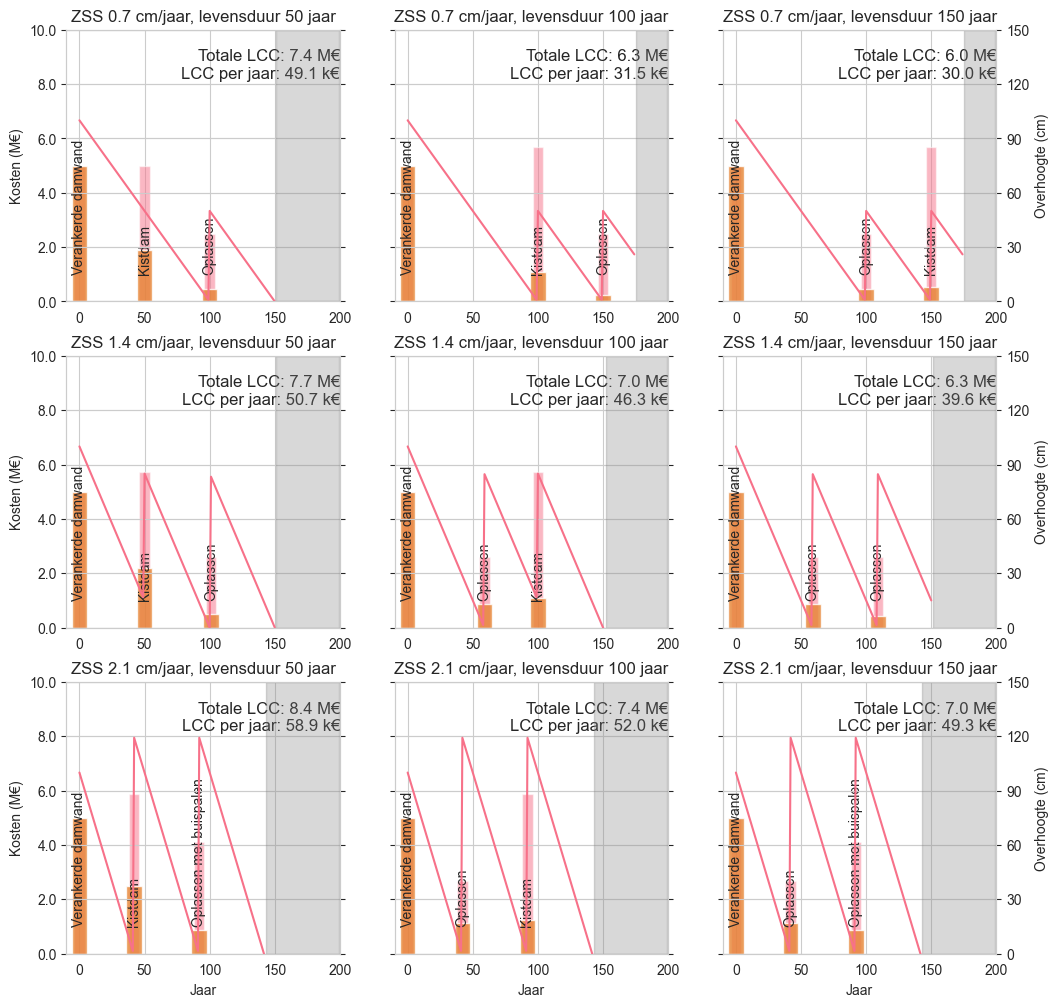

In [8]:
from matplotlib.ticker import MaxNLocator

def LCC_in_time_plot(ax_id, costs, lcc, overhoogtes, structures, total_horizon, scenario, subplot_index=0, **kwargs):
    ax = ax_id

    ax.bar([t for t, c in costs], [c for t, c in costs], label='Kosten', alpha=0.5, width=8)
    ax.bar([t for t, c in lcc], [list(c.values())[0] for t, c in lcc], label='LCC', alpha=0.8, width=12)

    if kwargs.get('measure_labels', True):
        for t, s in structures:
            ax.text(t, kwargs.get('text_y', 1e6), s, rotation=90, verticalalignment='bottom', horizontalalignment='center', fontsize=10)

    ax.set_ylim(top=kwargs.get('ylim_cost_max', 15e6), bottom=0)
    ax.set_xlim(-10, 200)

    ax2 = ax.twinx()
    ax2.plot(overhoogtes, label='Overhoogte')
    ax2.fill_between(range(len(overhoogtes), 200), 0, 150, color='grey', alpha=0.3, label='Niet doorgerekend')
    ax2.set_ylim(top=150, bottom=0)

    ax.yaxis.set_major_locator(MaxNLocator(nbins=kwargs.get('grid_lines', 6)))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=kwargs.get('grid_lines', 6)))
    ax.set_title(f"ZSS {scenario[0]} cm/jaar, levensduur {scenario[1]} jaar")

    if subplot_index % 3 != 0:
        ax.set_yticklabels([])
    else:
        ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
        ax.set_ylabel('Kosten (M€)')

    if subplot_index % 3 != 2:
        ax2.set_yticklabels([])
    else:
        ax2.set_ylabel('Overhoogte (cm)')

    if subplot_index >= 6:
        ax.set_xlabel('Jaar')

    total_lcc_value = sum([list(c.values())[0] for t, c in lcc])
    ax.text(
        1.0,
        0.93,
        f"Totale LCC: {total_lcc_value/1e6:.1f} M€\nLCC per jaar: {(total_lcc_value/1e3)/(total_horizon-2025):.1f} k€",
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
    )

fig, axes = plt.subplots(figsize=(12, 12), ncols=3, nrows=3)
ax_ids = axes.flatten()

scenario_keys = list(analysis.scenarios.keys())
for i, scenario in enumerate(scenario_keys):
    scenario_result = analysis.scenarios[scenario]
    LCC_in_time_plot(
        ax_ids[i],
        scenario_result.costs,
        lcc[scenario],
        scenario_result.overhoogte,
        scenario_result.structures,
        total_horizon[scenario],
        scenario,
        subplot_index=i,
        ylim_cost_max=10e6,
        grid_lines=5,
    )

In [9]:
def compute_investment_cycles_soil(ZSS_speed, dh_crest, start_overhoogte, K_V, V_dh, number_of_investments = 3, outer_measures = False, **kwargs):
    t_grid = np.arange(0, 175, 1)
    overhoogte = [start_overhoogte]
    investments_made = 0
    costs_made = []
    volumes_added = []
    total_increase = 0
    if outer_measures:
        kosten_verruwing = kwargs.get('kosten_verruwing', 1e8)
        kosten_kruinmuur = kwargs.get('kosten_kruinmuur', 1e8)
        kruinmuur_built = False
        verruwing_built = False
    else:
        pass

    total_horizon = t_grid[-1]
    for t in t_grid:
        overhoogte.append(overhoogte[-1] - (dh_crest) - (ZSS_speed))
        if overhoogte[-1] < 0:
            if investments_made >= number_of_investments:
                total_horizon = t
                break
            if outer_measures:
                #add verruwing or kruinmuur
                if not verruwing_built:
                    costs_made.append((t, kosten_verruwing))
                    volumes_added.append((t, 0))
                    overhoogte[-1] += 60 #verruwing boventalud eq. aan 60 cm kruinverhoging
                    verruwing_built = True
                    investments_made += 1
                    continue
                elif not kruinmuur_built:
                    costs_made.append((t, kosten_kruinmuur))
                    volumes_added.append((t, 0))
                    overhoogte[-1] += 60 #kruinmuur eq. aan 60 cm kruinverhoging
                    kruinmuur_built = True
                    investments_made += 1
                    continue

            dcrest = dh_crest * 50 + ZSS_speed * 50
            total_increase += dcrest
            overhoogte[-1] += dcrest
            volume_added = V_dh[0]* (dcrest/100) +V_dh[1]
            cost_made = K_V[0] * volume_added + K_V[1]
            costs_made.append((t, cost_made))
            volumes_added.append((t, volume_added))
            investments_made += 1

    return costs_made, volumes_added, overhoogte,total_horizon

lcc_soil = {}
costs_soil = {}
volumes_soil = {}
overhoogtes_soil = {}
total_horizons_soil = {}
for ZSS_speed in scenario_ZSS_cm_jaar:
    costs_soil[ZSS_speed], volumes_soil[ZSS_speed], overhoogtes_soil[ZSS_speed], total_horizons_soil[ZSS_speed] = compute_investment_cycles_soil(ZSS_speed = ZSS_speed, dh_crest = 0.3, start_overhoogte = 100, K_V = K_V_soil, V_dh = V_dh_soil, number_of_investments = 3)
    #reorder investments to be good input for LCC computation: sort by year
    investment_list = {f'Grondversterking {count}': (cost, 2025+year, 50) for count, (year, cost) in enumerate(costs_soil[ZSS_speed])}
    lcc_list = compute_lcc(investment_list, total_horizon = total_horizons_soil[ZSS_speed])
    lcc_soil[ZSS_speed] = ([(costs_soil[ZSS_speed][count][0], {lcc[0]: lcc[1]}) for count, lcc in enumerate(lcc_list.items())])
    #add t=0 reinforcement:
    lcc_soil[ZSS_speed].insert(0, (0, {'Initiele grondversterking': C_init_grondversterking_2025})) #add vastgoedkosten
print(costs_soil)
print(lcc_soil)

{0.7: [(99, 1031350.9392269484), (149, 1031350.9392269484)], 1.4: [(58, 1173300.1388582734), (108, 1173300.1388582734), (158, 1173300.1388582734)], 2.1: [(41, 1315249.3384895984), (91, 1315249.3384895984), (141, 1315249.3384895984)]}
{0.7: [(0, {'Initiele grondversterking': 2617010.27}), (99, {'Grondversterking 0': 197786.20412188812}), (149, {'Grondversterking 1': 92047.88136199818})], 1.4: [(0, {'Initiele grondversterking': 2617010.27}), (58, {'Grondversterking 0': 397882.46895415825}), (108, {'Grondversterking 1': 198544.13124883902}), (158, {'Grondversterking 2': 93231.58875443142})], 2.1: [(0, {'Initiele grondversterking': 2617010.27}), (41, {'Grondversterking 0': 564935.6858367173}), (91, {'Grondversterking 1': 281904.0136418804}), (141, {'Grondversterking 2': 129996.59649560563})]}


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25008\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25008\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_25008\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])


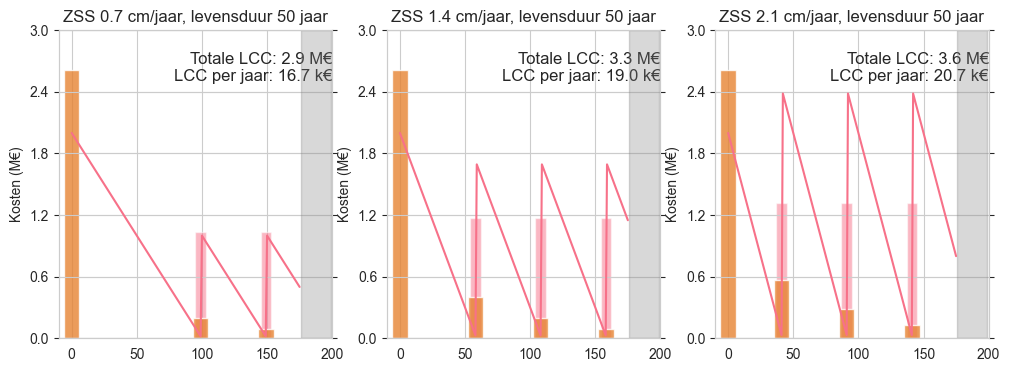

In [10]:
#plot LCC and costs for soil investments
fig, axes = plt.subplots(figsize=(12,4), ncols=3, nrows=1)
for i, ZSS_speed in enumerate(scenario_ZSS_cm_jaar):
    LCC_in_time_plot(axes[i], costs_soil[ZSS_speed], lcc_soil[ZSS_speed], overhoogtes_soil[ZSS_speed], [(t, f'Grondversterking {count}') for count, (t, c) in enumerate(costs_soil[ZSS_speed])], total_horizons_soil[ZSS_speed]+2025, (ZSS_speed, 50),ylim_cost_max=3e6,text_y=1e5,grid_lines=5,measure_labels=False)



In [11]:
lifespan = [50, 100, 150]

# FIRST FOR STRUCTURES (use structured scenario outputs)
lcc_df_structure = pd.DataFrame(
    index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar],
    columns=[f"{life} jaar" for life in lifespan],
)
lcc_per_year_df_structure = lcc_df_structure.copy()
lcc_per_year_df = lcc_df_structure.copy()

for (ZSS_speed, life), scenario_result in analysis.scenarios.items():
    total_lcc_value = sum([list(c.values())[0] for t, c in lcc[(ZSS_speed, life)]])
    lcc_df_structure.loc[f"{ZSS_speed} cm/jaar", f"{life} jaar"] = total_lcc_value
    lcc_per_year_df_structure.loc[f"{ZSS_speed} cm/jaar", f"{life} jaar"] = (
        total_lcc_value / (total_horizon[(ZSS_speed, life)] - 2025)
    )

# THEN FOR SOIL
lcc_soil_df = pd.DataFrame(
    index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar],
    columns=["n.v.t."],
)
lcc_per_year_soil_df = lcc_soil_df.copy()

for ZSS_speed in scenario_ZSS_cm_jaar:
    lcc_soil_df.loc[f"{ZSS_speed} cm/jaar", "n.v.t."] = sum([list(c.values())[0] for t, c in lcc_soil[ZSS_speed]])
    lcc_per_year_soil_df.loc[f"{ZSS_speed} cm/jaar", "n.v.t."] = (
        sum([list(c.values())[0] for t, c in lcc_soil[ZSS_speed]]) / total_horizons_soil[ZSS_speed]
    )

lcc_df_structure = lcc_df_structure.astype(float)
lcc_per_year_df_structure = lcc_per_year_df_structure.astype(float)
lcc_soil_df = lcc_soil_df.astype(float)
lcc_per_year_soil_df = lcc_per_year_soil_df.astype(float)

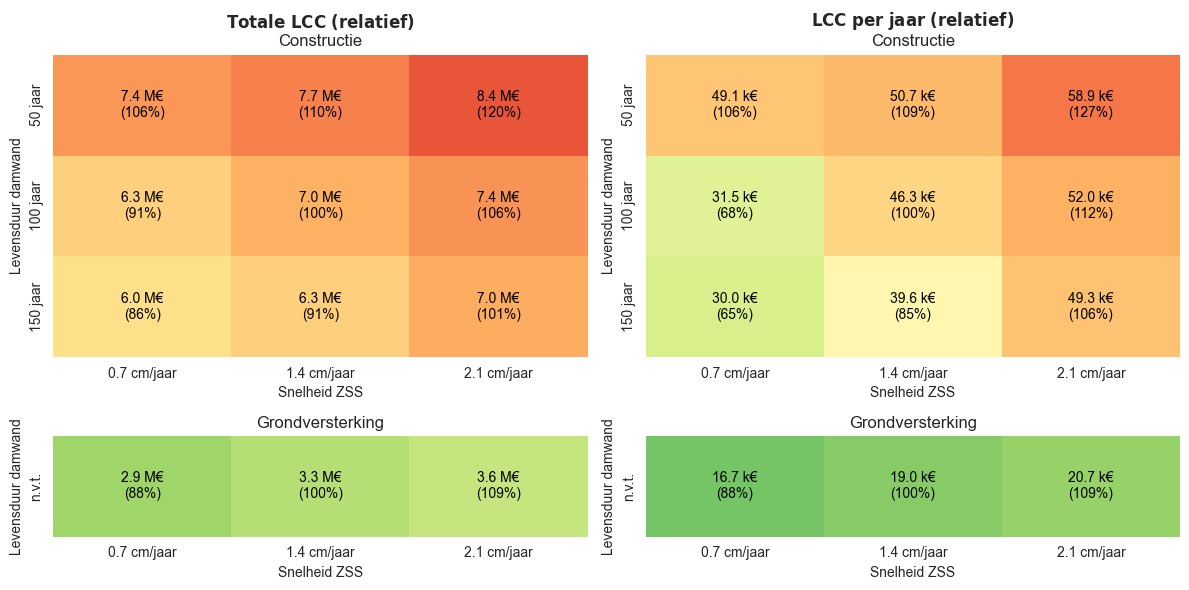

In [12]:
def plot_heatmap_lcc(lcc_df, normalization_value, ax_id, normalization_unit = 1e6, vmax = 10e6):
    ax = ax_id
    sns.heatmap(lcc_df.T, annot=False, cmap="RdYlGn_r", ax=ax, cbar=False, vmin=0.0, vmax=vmax)
    #add annotation from lcc_df with percentage in brackets on second line:
    for i in range(lcc_df.shape[0]):
        for j in range(lcc_df.shape[1]):
            if normalization_unit == 1e6:
                ax.text(i+0.5, j+0.5, f"{lcc_df.iloc[i,j]/1e6:,.1f} M€\n({lcc_df.iloc[i,j]/normalization_value:.0%})", ha='center', va='center', color='black')
            elif normalization_unit == 1e3:
                ax.text(i+0.5, j+0.5, f"{lcc_df.iloc[i,j]/1e3:,.1f} k€\n({lcc_df.iloc[i,j]/normalization_value:.0%})", ha='center', va='center', color='black')
            else:
                raise ValueError("Normalization value must be 1e6 or 1e3")
    ax.set_title(r"$\mathbf{Totale\ LCC\ (relatief)}$" + "\nConstructie")
    ax.set_xlabel("Snelheid ZSS")
    ax.set_ylabel("Levensduur damwand")


#plot the heatmaps
fig, axes = plt.subplots(figsize=(12,6), ncols=2, nrows=2, height_ratios=[3,1])

#use cmap green to red for lcc_df and blue to yellow for lcc_per_year_df

plot_heatmap_lcc(lcc_df_structure, lcc_df_structure.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "100 jaar"], axes[0,0], vmax = 10e6)

plot_heatmap_lcc(lcc_per_year_df_structure, lcc_per_year_df_structure.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "100 jaar"], axes[0,1], normalization_unit = 1e3, vmax = 75e3)

plot_heatmap_lcc(lcc_soil_df, lcc_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "n.v.t."], axes[1,0], vmax = 10e6)

plot_heatmap_lcc(lcc_per_year_soil_df, lcc_per_year_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "n.v.t."], axes[1,1], normalization_unit = 1e3, vmax = 75e3)

axes[0,0].set_title(r"$\mathbf{Totale\ LCC\ (relatief)}$" + "\nConstructie")
axes[0,1].set_title(r"$\mathbf{LCC\ per\ jaar\ (relatief)}$" + "\nConstructie")
axes[0,0].set_xlabel("Snelheid ZSS")
axes[0,1].set_xlabel("Snelheid ZSS")
axes[0,0].set_ylabel("Levensduur damwand")

axes[1,0].set_title("Grondversterking")
axes[1,1].set_title("Grondversterking")

fig.tight_layout()


## Gevoeligheidsanalyse 2: invloed van buitentalud op opgave

Hier kijken we naar de invloed van het buitentalud op de opgave.

In [ ]:
kosten_verruwing = 2200 * 100  #verruwing boventalud eq. aan 60 cm kruinverhoging. 9 meter talud, 250 meter lang dus ~2200 m2 te verruwen. Kosten 100 euro/m2
kosten_kruinmuur = 561271 #kruinmuur van 60 cm

In [ ]:


lcc_soil_outer = {}
costs_soil_outer = {}
volumes_soil_outer = {}
overhoogtes_soil_outer = {}
total_horizons_soil_outer = {}
for ZSS_speed in scenario_ZSS_cm_jaar:
    costs_soil_outer[ZSS_speed], volumes_soil_outer[ZSS_speed], overhoogtes_soil_outer[ZSS_speed], total_horizons_soil_outer[ZSS_speed] = compute_investment_cycles_soil(ZSS_speed = ZSS_speed, dh_crest = 0.3, start_overhoogte = 100, K_V = K_V_soil, V_dh = V_dh_soil, number_of_investments = 3, outer_measures = True, kosten_verruwing = kosten_verruwing, kosten_kruinmuur = 561271)
    # costs_soil_outer[ZSS_speed], volumes_soil_outer[ZSS_speed], overhoogtes_soil_outer[ZSS_speed], total_horizons_soil_outer[ZSS_speed] = compute_investment_cycles_soil_outer_with_outer_measures(ZSS_speed = ZSS_speed, dh_crest = 0.3, start_overhoogte = 100, K_V = K_V_soil, V_dh = V_dh_soil, number_of_investments = 3, outer_measures = True, kosten_verruwing = kosten_verruwing, kosten_kruinmuur = 561271)
    #reorder investments to be good input for LCC computation: sort by year
    investment_list = {f'Grondversterking {count}': (cost, 2025+year, 50) for count, (year, cost) in enumerate(costs_soil_outer[ZSS_speed])}
    lcc_list = compute_lcc(investment_list, total_horizon = total_horizons_soil_outer[ZSS_speed])
    lcc_soil_outer[ZSS_speed] = ([(costs_soil_outer[ZSS_speed][count][0], {lcc[0]: lcc[1]}) for count, lcc in enumerate(lcc_list.items())])
    #add t=0 reinforcement:
    lcc_soil_outer[ZSS_speed].insert(0, (0, {'Initiele grondversterking': C_init_grondversterking_2025})) #add vastgoedkosten

#convert to DataFrame for plotting
lcc_soil_outer_df = pd.DataFrame(
    index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar],
    columns=["n.v.t."],
)
lcc_per_year_soil_outer_df = lcc_soil_outer_df.copy()

for ZSS_speed in scenario_ZSS_cm_jaar:
    lcc_soil_outer_df.loc[f"{ZSS_speed} cm/jaar", "n.v.t."] = sum([list(c.values())[0] for t, c in lcc_soil_outer[ZSS_speed]])
    lcc_per_year_soil_outer_df.loc[f"{ZSS_speed} cm/jaar", "n.v.t."] = (
        sum([list(c.values())[0] for t, c in lcc_soil_outer[ZSS_speed]]) / total_horizons_soil_outer[ZSS_speed]
    )



C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.s

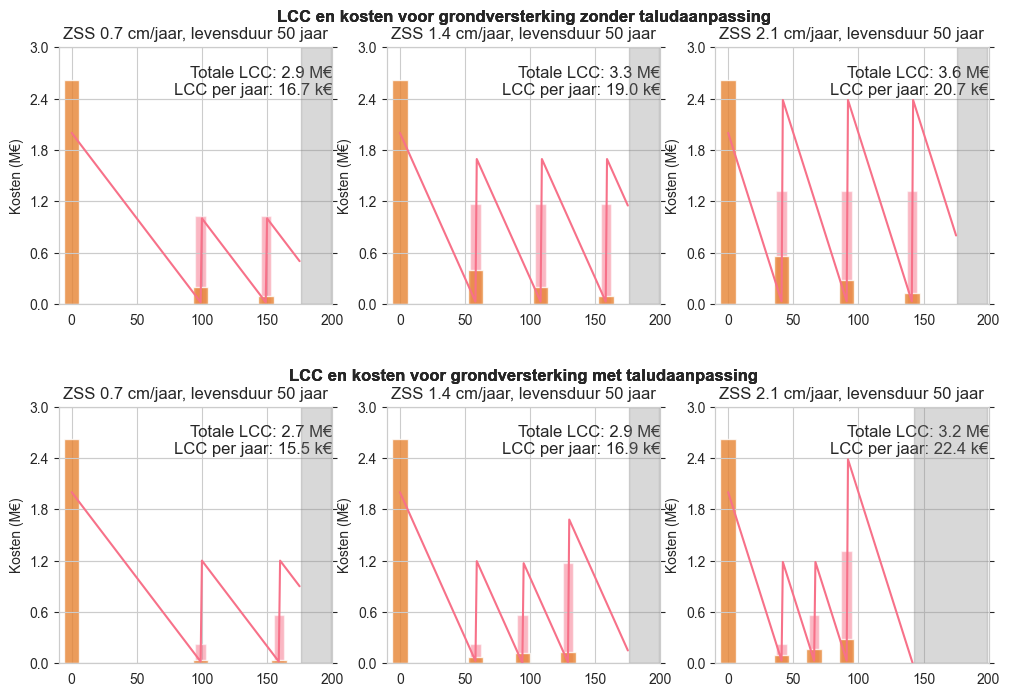

In [ ]:
#plot LCC and costs for soil investments
fig, axes = plt.subplots(figsize=(12,8), ncols=3, nrows=2)
for i, ZSS_speed in enumerate(scenario_ZSS_cm_jaar):
    LCC_in_time_plot(axes[0,i], costs_soil[ZSS_speed], lcc_soil[ZSS_speed], overhoogtes_soil[ZSS_speed], [(t, f'Grondversterking {count}') for count, (t, c) in enumerate(costs_soil[ZSS_speed])], total_horizons_soil[ZSS_speed]+2025, (ZSS_speed, 50),ylim_cost_max=3e6,text_y=1e5,grid_lines=5,measure_labels=False)
    #add title above first row of plots
    axes[0,1].text(x = 0.5, y = 1.1, s = "LCC en kosten voor grondversterking zonder taludaanpassing", fontsize=12, weight='bold', ha='center', transform=axes[0,1].transAxes)
    
for i, ZSS_speed in enumerate(scenario_ZSS_cm_jaar):
    LCC_in_time_plot(axes[1,i], costs_soil_outer[ZSS_speed], lcc_soil_outer[ZSS_speed], overhoogtes_soil_outer[ZSS_speed], [(t, f'Grondversterking {count}') for count, (t, c) in enumerate(costs_soil_outer[ZSS_speed])], total_horizons_soil_outer[ZSS_speed]+2025, (ZSS_speed, 50),ylim_cost_max=3e6,text_y=1e5,grid_lines=5,measure_labels=False)
    #add title above second row of plots
    axes[1,1].text(x = 0.5, y = 1.1, s = "LCC en kosten voor grondversterking met taludaanpassing", fontsize=12, weight='bold', ha='center', transform=axes[1,1].transAxes)
    #add spacing between the two rows of plots
    fig.subplots_adjust(hspace=.4)

# fig.tight_layout()



Scenario ZSS snelheid: 0.7 cm/jaar
Scenario levensduur: 50 jaar
In 2075 wordt de constructie vervangen door een kistdam. Kosten: 5,000,000 euro
In 2125 wordt een verruwing aangelegd. Kosten: 220,000 euro
Scenario levensduur: 100 jaar
In 2125 wordt een verruwing aangelegd. Kosten: 220,000 euro
In 2125 wordt de kruin verhoogd met 50.0 cm en de constructie vervangen door een kistdam. Kosten: 5,903,651 euro
In 2175 wordt een kruinmuur gebouwd. Kosten: 561,271 euro
Scenario levensduur: 150 jaar
In 2125 wordt een verruwing aangelegd. Kosten: 220,000 euro
In 2175 wordt een kruinmuur gebouwd. Kosten: 561,271 euro
In 2175 wordt de kruin verhoogd met 50.0 cm en de constructie vervangen door een kistdam. Kosten: 6,244,922 euro
Scenario ZSS snelheid: 1.4 cm/jaar
Scenario levensduur: 50 jaar
In 2075 wordt de constructie vervangen door een kistdam en de kruin verhoogd met 69.99999999999997 cm. Kosten: 5,743,421 euro
In 2126 wordt een verruwing aangelegd. Kosten: 220,000 euro
Scenario levensduur: 100

C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_37464\3386905810.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{(y/1e6):.1f}" for y in ax.get_yticks()])


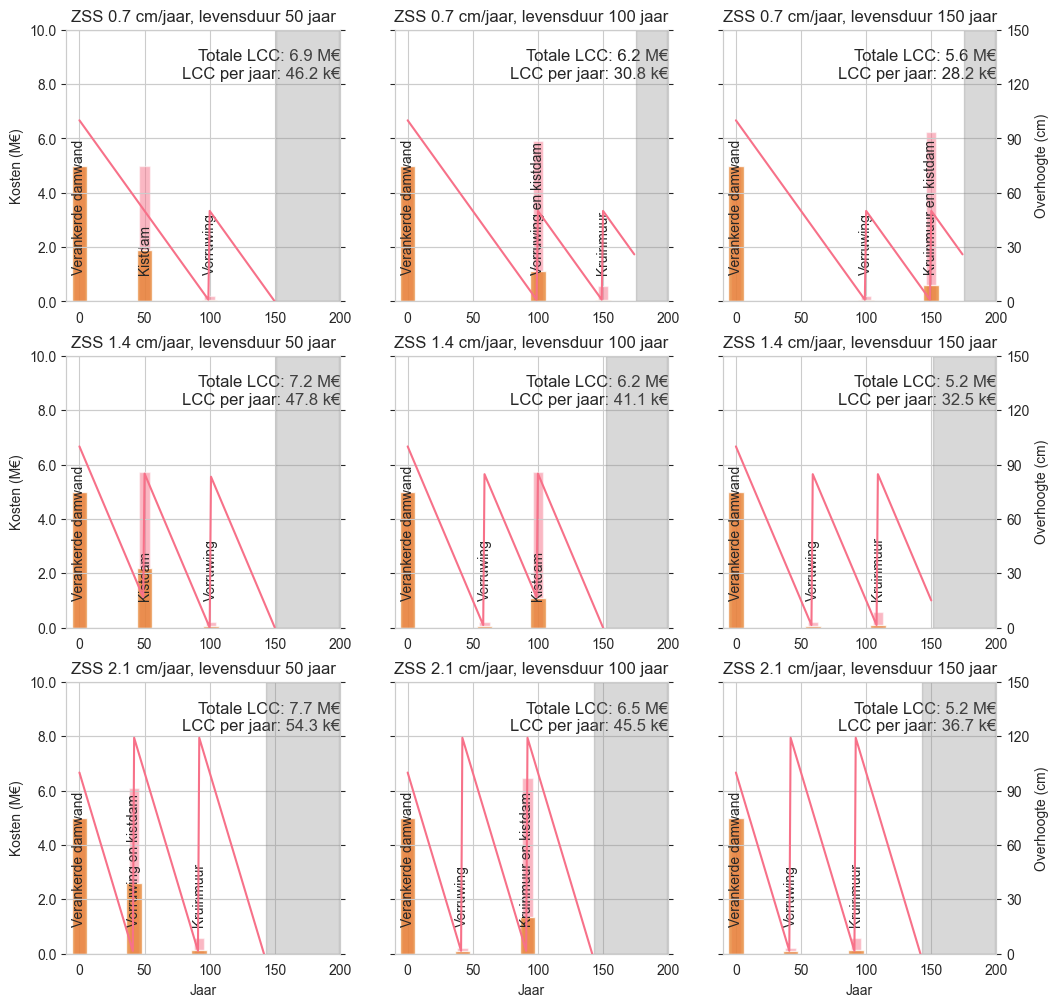

In [ ]:
results_dict_outer = {}
for ZSS_speed in scenario_ZSS_cm_jaar:
    print(f"Scenario ZSS snelheid: {ZSS_speed} cm/jaar")
    for life in lifespan:
        print(f"Scenario levensduur: {life} jaar")

        costs_made_structure_outer, volumes_added_structure_outer, structures_made_structure_outer, crest_increase_structure_outer, overhoogte_structure_outer = compute_scenario_structure(
            ZSS_speed, life, h_0, dh_crest, costs_dict, V_dh_structure, K_V_structure, outer_measures=True, kosten_verruwing=kosten_verruwing, kosten_kruinmuur=kosten_kruinmuur
        )

        results_dict_outer[(ZSS_speed, life)] = ScenarioResult(
            zss_speed=ZSS_speed,
            lifespan=life,
            costs=costs_made_structure_outer,
            volumes=volumes_added_structure_outer,
            structures=structures_made_structure_outer,
            crest_increases=crest_increase_structure_outer,
            overhoogte=overhoogte_structure_outer,
        )
analysis_outer = AdaptationPathwayAnalysis(
    scenario_parameters={
        'costs_dict': costs_dict,
        'h_0': h_0,
        'dh_crest': dh_crest,
        'V_dh_structure': V_dh_structure,
        'K_V_structure': K_V_structure,
        'scenario_ZSS_cm_jaar': scenario_ZSS_cm_jaar,
        'lifespan': lifespan,
    },
    scenarios=results_dict_outer,
)
# compute LCC from structured scenario results
lcc_structure_outer = {}
total_horizon_structure_outer = {}

for scenario_key, scenario_result in analysis_outer.scenarios.items():
    ZSS_speed, life = scenario_key
    cost_list = scenario_result.costs
    structure_list = scenario_result.structures

    lcc_structure_outer[scenario_key] = []
    total_horizon_structure_outer[scenario_key] = 2025 + cost_list[-1][0] + 50

    for count, (year, cost) in enumerate(cost_list):
        if structure_list[count][1] == 'Kistdam':
            structure_lifespan = 100
        else:
            structure_lifespan = 50

        lcc_value = compute_lcc(
            {structure_list[count][1]: (cost, 2025 + year, structure_lifespan)},
            total_horizon=total_horizon_structure_outer[scenario_key],
        )
        lcc_structure_outer[scenario_key].append((year, lcc_value))

# FIRST FOR STRUCTURES (use structured scenario outputs)
lcc_df_structure_outer = pd.DataFrame(
    index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar],
    columns=[f"{life} jaar" for life in lifespan],
)
lcc_per_year_df_structure_outer = lcc_df_structure_outer.copy()
lcc_per_year_df_outer = lcc_df_structure_outer.copy()

for (ZSS_speed, life), scenario_result in analysis_outer.scenarios.items():
    total_lcc_value = sum([list(c.values())[0] for t, c in lcc_structure_outer[(ZSS_speed, life)]])
    lcc_df_structure_outer.loc[f"{ZSS_speed} cm/jaar", f"{life} jaar"] = total_lcc_value
    lcc_per_year_df_structure_outer.loc[f"{ZSS_speed} cm/jaar", f"{life} jaar"] = (
        total_lcc_value / (total_horizon_structure_outer[(ZSS_speed, life)] - 2025)
    )

fig, axes = plt.subplots(figsize=(12, 12), ncols=3, nrows=3)
ax_ids = axes.flatten()

scenario_keys = list(analysis_outer.scenarios.keys())
for i, scenario in enumerate(scenario_keys):
    scenario_result = analysis_outer.scenarios[scenario]
    LCC_in_time_plot(
        ax_ids[i],
        scenario_result.costs,
        lcc_structure_outer[scenario],
        scenario_result.overhoogte,
        scenario_result.structures,
        total_horizon_structure_outer[scenario],
        scenario,
        subplot_index=i,
        ylim_cost_max=10e6,
        grid_lines=5,
    )

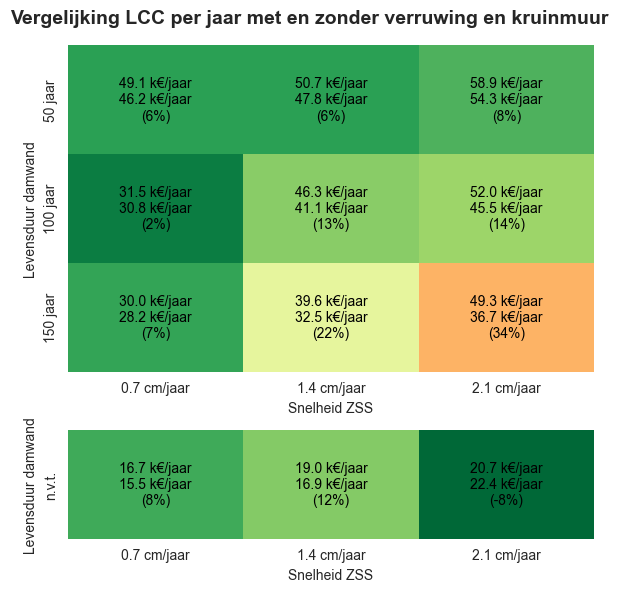

In [ ]:
def plot_heatmap_lcc_differences(lcc_1, lcc_2, ax_id, normalization_unit = 1e6, vmax = 1.0):
    ax = ax_id
    lcc_ratio = (lcc_1 / lcc_2)-1
    lcc_ratio = lcc_ratio.astype(float)
    sns.heatmap(lcc_ratio, annot=False, cmap="RdYlGn_r", ax=ax, cbar=False, vmin=0.0, vmax=vmax)
    # add annotation from lcc_ratio with percentage in brackets on second line
    for j in range(lcc_ratio.shape[0]):  # rows (y-axis)
        for i in range(lcc_ratio.shape[1]):  # columns (x-axis)
            if normalization_unit == 1e6:
                ax.text(i+0.5, j+0.5, f"{lcc_1.iloc[j,i]/1e6:,.1f} M€\n{lcc_2.iloc[j,i]/1e6:,.1f} M€\n({lcc_ratio.iloc[j,i]:.0%})", ha='center', va='center', color='black')
            elif normalization_unit == 1e3:
                ax.text(i+0.5, j+0.5, f"{lcc_1.iloc[j,i]/1e3:,.1f} k€/jaar\n{lcc_2.iloc[j,i]/1e3:,.1f} k€/jaar\n({lcc_ratio.iloc[j,i]:.0%})", ha='center', va='center', color='black')
            else:
                raise ValueError("Normalization value must be 1e6 or 1e3")

    ax.set_xlabel("Snelheid ZSS")
    ax.set_ylabel("Levensduur damwand")


#plot the heatmaps
# fig, axes = plt.subplots(figsize=(12,6), ncols=2, nrows=2, height_ratios=[3,1])
fig, axes = plt.subplots(figsize=(6,6), ncols=1, nrows=2, height_ratios=[3,1])

#use cmap green to red for lcc_df and blue to yellow for lcc_per_year_df

plot_heatmap_lcc_differences(lcc_per_year_df_structure.T, lcc_per_year_df_structure_outer.T, axes[0], vmax = .5,normalization_unit = 1e3)

plot_heatmap_lcc_differences(lcc_per_year_soil_df.T, lcc_per_year_soil_outer_df.T, axes[1], vmax = .5,normalization_unit = 1e3)
# plot_heatmap_lcc(lcc_per_year_df_structure, lcc_per_year_df_structure.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "100 jaar"], axes[0,1], normalization_unit = 1e3, vmax = 75e3)

# plot_heatmap_lcc(lcc_soil_df, lcc_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "n.v.t."], axes[1,0], vmax = 10e6)

# plot_heatmap_lcc(lcc_per_year_soil_df, lcc_per_year_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", "n.v.t."], axes[1,1], normalization_unit = 1e3, vmax = 75e3)

# axes[0,0].set_title(r"$\mathbf{Totale\ LCC\ (relatief)}$" + "\nConstructie")
# axes[0,1].set_title(r"$\mathbf{LCC\ per\ jaar\ (relatief)}$" + "\nConstructie")
axes[0].set_xlabel("Snelheid ZSS")
# axes[0,1].set_xlabel("Snelheid ZSS")
axes[0].set_ylabel("Levensduur damwand")
fig.suptitle("Vergelijking LCC per jaar met en zonder verruwing en kruinmuur", fontsize=14, weight='bold')
# axes[1,0].set_title("Grondversterking")
# axes[1,1].set_title("Grondversterking")

fig.tight_layout()


## Gevoeligheidsanalyse kosten bebouwing

1. Analyse van het omslagpunt van de bebouwingsprijs: we pakken per scenario de kosten bebouwing en verhogend ie met een factor
2. We kijken naar de constructieve optie waarbij we de damwand nu bouwen, maar op een willekeurig moment in de tijd tussen jaar 25 en 100 kunnen we het pand opkopen voor 200k€ (TBD), en 400 k€ voor de grond.

ZSS snelheid: 0.7 cm/jaar, LCC per jaar bij 100 jaar levensduur: 31.5 k€
ZSS snelheid: 1.4 cm/jaar, LCC per jaar bij 100 jaar levensduur: 46.3 k€
ZSS snelheid: 2.1 cm/jaar, LCC per jaar bij 100 jaar levensduur: 52.0 k€


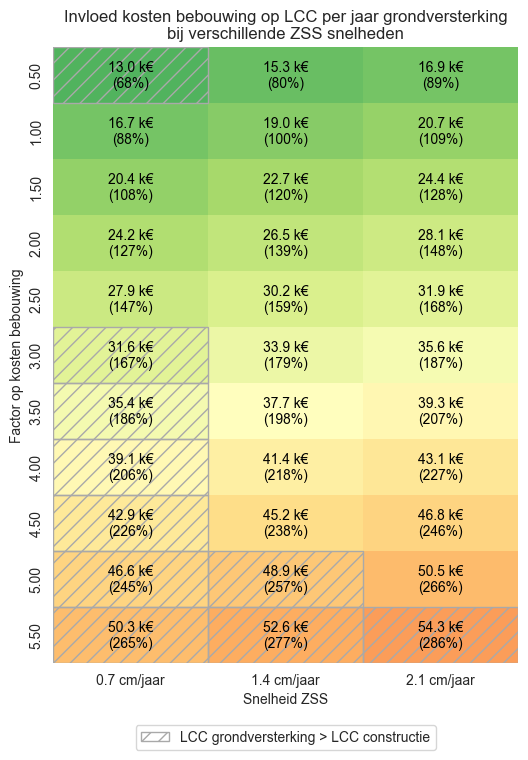

In [ ]:
lcc_soil = {}
costs_soil = {}
volumes_soil = {}
overhoogtes_soil = {}
total_horizons_soil = {}
kostenfactoren = np.arange(0.5, 6.0, 0.5)
basiskosten_bebouwing = 1.3e6
bouwkosten_2025 = C_init_grondversterking_2025 - basiskosten_bebouwing
for kostenfactor_bebouwing in kostenfactoren:
    costs_soil[kostenfactor_bebouwing] = {}
    volumes_soil[kostenfactor_bebouwing] = {}
    lcc_soil[kostenfactor_bebouwing] = {}
    overhoogtes_soil[kostenfactor_bebouwing] = {}
    total_horizons_soil[kostenfactor_bebouwing] = {}
    for ZSS_speed in scenario_ZSS_cm_jaar:
        costs_soil[kostenfactor_bebouwing][ZSS_speed], volumes_soil[kostenfactor_bebouwing][ZSS_speed], overhoogtes_soil[kostenfactor_bebouwing][ZSS_speed], total_horizons_soil[kostenfactor_bebouwing][ZSS_speed] = compute_investment_cycles_soil(ZSS_speed = ZSS_speed, dh_crest = 0.3, start_overhoogte = 100, K_V = K_V_soil, V_dh = V_dh_soil, number_of_investments = 3)
        #reorder investments to be good input for LCC computation: sort by year
        investment_list = {f'Grondversterking {count}': (cost, 2025+year, 50) for count, (year, cost) in enumerate(costs_soil[kostenfactor_bebouwing][ZSS_speed])}
        lcc_list = compute_lcc(investment_list, total_horizon = total_horizons_soil[kostenfactor_bebouwing][ZSS_speed])
        lcc_soil[kostenfactor_bebouwing][ZSS_speed] = ([(costs_soil[kostenfactor_bebouwing][ZSS_speed][count][0], {lcc[0]: lcc[1]}) for count, lcc in enumerate(lcc_list.items())])
        #add t=0 reinforcement:
        lcc_soil[kostenfactor_bebouwing][ZSS_speed].insert(0, (0, {'Initiele grondversterking': bouwkosten_2025 + basiskosten_bebouwing * kostenfactor_bebouwing})) #add vastgoedkosten

#make dataframe
lcc_soil_df = pd.DataFrame(
    index=[f"{ZSS_speed} cm/jaar" for ZSS_speed in scenario_ZSS_cm_jaar],
    columns=[f"{kostenfactor_bebouwing:.2f}" for kostenfactor_bebouwing in kostenfactoren],
)
lcc_per_year_soil_df = lcc_soil_df.copy()
for kostenfactor_bebouwing in kostenfactoren:
    for ZSS_speed in scenario_ZSS_cm_jaar:
        lcc_soil_df.loc[f"{ZSS_speed} cm/jaar", f"{kostenfactor_bebouwing:.2f}"] = sum([list(c.values())[0] for t, c in lcc_soil[kostenfactor_bebouwing][ZSS_speed]])
        lcc_per_year_soil_df.loc[f"{ZSS_speed} cm/jaar", f"{kostenfactor_bebouwing:.2f}"] = (
            sum([list(c.values())[0] for t, c in lcc_soil[kostenfactor_bebouwing][ZSS_speed]]) / total_horizons_soil[kostenfactor_bebouwing][ZSS_speed]
        )
lcc_per_year_soil_df = lcc_per_year_soil_df.astype(float)

#plot a heatmap of the LCC per year for different building cost factors
fig, ax = plt.subplots(figsize=(6,8))
plot_heatmap_lcc(lcc_per_year_soil_df, lcc_per_year_soil_df.loc[f"{scenario_ZSS_cm_jaar[1]} cm/jaar", f"{kostenfactoren[1]:.2f}"], ax, normalization_unit = 1e3, vmax = 75e3)
ax.set_ylabel("Factor op kosten bebouwing")

#bepaal voor elke ZSS in structure de kosten bij 100 jaar levensduur.
for ZSS_speed in scenario_ZSS_cm_jaar:
    lcc_value = lcc_per_year_df_structure.loc[f"{ZSS_speed} cm/jaar", "100 jaar"]
    print(f"ZSS snelheid: {ZSS_speed} cm/jaar, LCC per jaar bij 100 jaar levensduur: {lcc_value/1e3:.1f} k€")
    #vind waar deze waarde in LCC_soil_per_year_df wordt overschreden, arceer deze vakken met grijze schuine strepen in de heatmap
    mask = lcc_per_year_soil_df.loc[f"{ZSS_speed} cm/jaar"] > lcc_value
    for col in lcc_per_year_soil_df.columns:
        if mask[col]:
            ax.add_patch(plt.Rectangle((lcc_per_year_soil_df.index.get_loc(f"{ZSS_speed} cm/jaar"), lcc_per_year_soil_df.columns.get_loc(col)), 1, 1, hatch='//', fill=False, edgecolor='darkgray'))
    #add patch for legend
ax.add_artist(plt.Rectangle((0, 0), 1, 1, hatch='//', fill=False, edgecolor='darkgray', label='LCC grondversterking > LCC constructie'))

ax.set_title('Invloed kosten bebouwing op LCC per jaar grondversterking\nbij verschillende ZSS snelheden')
ax.legend(bbox_to_anchor=(.5, -0.1), loc='upper center', borderaxespad=0., fontsize=10)

Effect van opkoop op resultaten van analyse met constructie

In [ ]:
opkoopmomenten = np.arange(25, 101, 5.)


compute_scenario_structure(ZSS_speed, life, h_0, dh_crest, costs_dict, V_dh_structure, K_V_structure, outer_measures=False, buyout_year = 1e99, **kwargs):